# 01 – First-Order Process Dynamics

**Manufacturing example:** A heated barrel zone reaching setpoint temperature.  
A first-order system is the simplest dynamic model — it appears in thermal processes, tank filling, and motor current buildup.

**Model:** &ensp; `tau * dy/dt = -y + K * u`  
**Key parameter:** The time constant `tau` determines how fast the process responds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Editable parameters ----
K = 1.0          # Process gain (steady-state output / input)
tau = 2.0        # Time constant [s] - thermal lag of a barrel zone
u_step = 100.0   # Step input magnitude (e.g., heater power %)
t_end = 12.0     # Simulation duration [s]
dt = 0.01        # Time step [s]
# -----------------------------

In [2]:
# Simulate first-order step response (Euler integration)
t = np.arange(0, t_end, dt)
y = np.zeros_like(t)

for i in range(1, len(t)):
    dydt = (-y[i-1] + K * u_step) / tau
    y[i] = y[i-1] + dydt * dt

final_value = K * u_step
print(f"Time constant  tau = {tau:.2f} s")
print(f"Final value        = {final_value:.2f}")
print(f"63% value at t=tau = {final_value * 0.632:.2f}")

Time constant  tau = 2.00 s
Final value        = 100.00
63% value at t=tau = 63.20


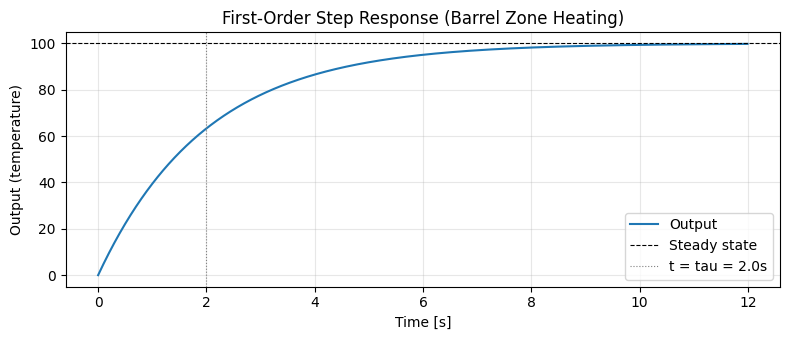

In [3]:
plt.figure(figsize=(8, 3.5))
plt.plot(t, y, label="Output")
plt.axhline(final_value, color="k", linestyle="--", linewidth=0.8, label="Steady state")
plt.axvline(tau, color="gray", linestyle=":", linewidth=0.8, label=f"t = tau = {tau}s")
plt.xlabel("Time [s]")
plt.ylabel("Output (temperature)")
plt.title("First-Order Step Response (Barrel Zone Heating)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Student Exercise

1. Double `tau` and re-run. How does the response speed change?
2. Set `K = 2.0`. What happens to the final value?
3. Try `tau = 0.5`. In what manufacturing process would you see such a fast first-order response?